In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchmetrics.classification import MulticlassConfusionMatrix
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision.ops import batched_nms

import cv2
import numpy as np
import os
import glob as glob
from PIL import Image

import albumentations as A
from albumentations.pytorch import ToTensorV2

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random

from collections import Counter

from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

from sklearn.metrics import confusion_matrix
import seaborn as sn
import pandas as pd


from torch.utils.tensorboard import SummaryWriter
writer = SummaryWriter()


In [2]:
BASE_DATASET_PATH = '../../datasets/KITTI/dataset'

valid_data_path = f'{BASE_DATASET_PATH}/valid_example/images/'
valid_lbl_path = f'{BASE_DATASET_PATH}/valid_example/labels/'

CHECKPOINT_FILE = "./checkpoints/best_full_999.pth.tar"

# KITTI Dataset
CLASSES = [ 
    'Car', 'Van', 'Truck', 'Pedestrian', 'Person_sitting', 'Cyclist', 'Tram', 'Misc'
]

colors = ['#ffffff','#3a3b7b','#6a6ecf','#8ca351','#fff100','#ff00ff','#833c39','#e598a0']


In [3]:
RESIZE_TO = 640 

ANCHORS = [
    # LARGE OBJECT SCALE (S=20)
    [
        (0.0737, 0.1407),
        (0.1173, 0.2590),
        (0.2270, 0.4612),
    ],
    # SMALL OBJECT SCALE (S=40)
    [
        (0.0223, 0.0665),
        (0.0420, 0.0937),
        (0.0294, 0.2288),
    ],
]

S = [RESIZE_TO // 32, RESIZE_TO // 16]

NUM_CLASSES = len(CLASSES) 
NUM_WORKERS = 5 * 2
BATCH_SIZE = 1
RESIZE_TO = 640 
LEARNING_RATE = 5e-4
WEIGHT_DECAY = 1e-4 
PIN_MEMORY = True
EPOCHS = 100
AMP = True

In [4]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE

'cuda'

In [5]:

test_transforms = A.Compose(
    [
        A.LongestMaxSize(max_size=RESIZE_TO),
        A.PadIfNeeded(
            min_height=RESIZE_TO, min_width=RESIZE_TO, border_mode=cv2.BORDER_CONSTANT
        ),
        A.Normalize(mean=[0, 0, 0], std=[1, 1, 1], max_pixel_value=255,),
        ToTensorV2(),
    ],
    bbox_params=A.BboxParams(format="yolo", min_visibility=0.4, label_fields=[]),
)

In [6]:
""" 
Information about architecture config:
"B" indicating a residual block
"S" is for scale prediction block
"U" is for upsampling the feature map
"""
config = [
    (32, 3, 1),
    (64, 3, 2),
    ["B", 4],
    (128, 3, 2),
    ["B", 6],
    (256, 3, 2),
    ["B", 8],
    (512, 3, 2),
    ["B", 8],
    (1024, 3, 2),
    ["B", 6],
    (512, 1, 1),
    (1024, 3, 1),
    "S",
    (256, 1, 1),
    "U",
    (256, 1, 1),
    (512, 3, 1),
    "S",
]

class CNNBlock(nn.Module):
    def __init__(self, in_channels, out_channels, bn_act=True, **kwargs):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, bias=not bn_act, **kwargs)
        self.bn = nn.BatchNorm2d(out_channels)
        self.leaky = nn.LeakyReLU(0.1)
        self.use_bn_act = bn_act

    def forward(self, x):
        if self.use_bn_act:
            return self.leaky(self.bn(self.conv(x)))
        else:
            return self.conv(x)


class ResidualBlock(nn.Module):
    def __init__(self, channels, use_residual=True, num_repeats=1):
        super().__init__()
        self.layers = nn.ModuleList()
        for repeat in range(num_repeats):
            self.layers += [
                nn.Sequential(
                    CNNBlock(channels, channels // 2, kernel_size=1),
                    CNNBlock(channels // 2, channels, kernel_size=3, padding=1),
                )
            ]

        self.use_residual = use_residual
        self.num_repeats = num_repeats

    def forward(self, x):
        for layer in self.layers:
            if self.use_residual:
                x = x + layer(x)
            else:
                x = layer(x)

        return x


class ScalePrediction(nn.Module):
    def __init__(self, num_classes, in_channels=3):
        super().__init__()
        self.pred = nn.Sequential(
            CNNBlock(in_channels, 2 * in_channels, kernel_size=3, padding=1),
            CNNBlock(
                2 * in_channels, 3 * (num_classes + 5), bn_act=False, kernel_size=1
            ),
        )
        
        self.num_classes = num_classes

    def forward(self, x):
        return (
            self.pred(x)
            .reshape(x.shape[0], 3, self.num_classes + 5, x.shape[2], x.shape[3])
            .permute(0, 1, 3, 4, 2)
        )

class SiStNet(nn.Module):
    def __init__(self, num_classes, in_channels=3):
        super().__init__()
        self.num_classes = num_classes
        self.in_channels = in_channels
        self.layers = self._create_conv_layers()

    def forward(self, x):
        outputs = []
        route_connections = []
        for layer in self.layers:
            if isinstance(layer, ScalePrediction):
                outputs.append(layer(x))
                continue

            x = layer(x)

            if isinstance(layer, ResidualBlock) and layer.num_repeats == 8:
                route_connections.append(x)

            elif isinstance(layer, nn.Upsample):
                x = torch.cat([x, route_connections[-1]], dim=1)
                route_connections.pop()

        return outputs

    def _create_conv_layers(self):
        layers = nn.ModuleList()
        in_channels = self.in_channels
        
        for module in config:
            if isinstance(module, tuple):
                out_channels, kernel_size, stride = module
                layers.append(
                    CNNBlock(
                        in_channels,
                        out_channels,
                        kernel_size=kernel_size,
                        stride=stride,
                        padding=1 if kernel_size == 3 else 0,
                    )
                )
                in_channels = out_channels

            elif isinstance(module, list):
                num_repeats = module[1]
                layers.append(ResidualBlock(in_channels, num_repeats=num_repeats))

            elif isinstance(module, str):
                if module == "S":
                    layers += [
                        ResidualBlock(in_channels, use_residual=False, num_repeats=1),
                        CNNBlock(in_channels, in_channels // 2, kernel_size=1),
                        ScalePrediction(in_channels=in_channels // 2, num_classes=self.num_classes),
                    ]
                    in_channels = in_channels // 2

                elif module == "U":
                    layers.append(nn.Upsample(scale_factor=2))
                    in_channels = in_channels * 3

        return layers

if __name__ == "__main__": 
    model = SiStNet(num_classes=NUM_CLASSES)

In [7]:
def iou_width_height(boxes1, boxes2):

    intersection = torch.min(boxes1[..., 0], boxes2[..., 0]) * torch.min(
        boxes1[..., 1], boxes2[..., 1]
    )

    union = (
        boxes1[..., 0] * boxes1[..., 1]
        + boxes2[..., 0] * boxes2[..., 1]
        - intersection
    )

    return intersection / (union + 1e-9)


In [8]:
def intersection_over_union(boxes_preds, boxes_labels, box_format="midpoint"):

    if box_format == "midpoint":
        box1_x1 = boxes_preds[..., 0:1] - boxes_preds[..., 2:3] / 2
        box1_y1 = boxes_preds[..., 1:2] - boxes_preds[..., 3:4] / 2
        box1_x2 = boxes_preds[..., 0:1] + boxes_preds[..., 2:3] / 2
        box1_y2 = boxes_preds[..., 1:2] + boxes_preds[..., 3:4] / 2

        box2_x1 = boxes_labels[..., 0:1] - boxes_labels[..., 2:3] / 2
        box2_y1 = boxes_labels[..., 1:2] - boxes_labels[..., 3:4] / 2
        box2_x2 = boxes_labels[..., 0:1] + boxes_labels[..., 2:3] / 2
        box2_y2 = boxes_labels[..., 1:2] + boxes_labels[..., 3:4] / 2

    elif box_format == "corners":
        box1_x1 = boxes_preds[..., 0:1]
        box1_y1 = boxes_preds[..., 1:2]
        box1_x2 = boxes_preds[..., 2:3]
        box1_y2 = boxes_preds[..., 3:4]

        box2_x1 = boxes_labels[..., 0:1]
        box2_y1 = boxes_labels[..., 1:2]
        box2_x2 = boxes_labels[..., 2:3]
        box2_y2 = boxes_labels[..., 3:4]

    else:
        raise ValueError(f"Unsupported box_format: {box_format}")

    x1 = torch.max(box1_x1, box2_x1)
    y1 = torch.max(box1_y1, box2_y1)
    x2 = torch.min(box1_x2, box2_x2)
    y2 = torch.min(box1_y2, box2_y2)

    intersection = (x2 - x1).clamp(min=0) * (y2 - y1).clamp(min=0)

    box1_area = torch.abs(
        (box1_x2 - box1_x1) * (box1_y2 - box1_y1)
    )

    box2_area = torch.abs(
        (box2_x2 - box2_x1) * (box2_y2 - box2_y1)
    )

    union = box1_area + box2_area - intersection

    return intersection / (union + 1e-9)

In [9]:
def load_full_checkpoint(checkpoint_path, model, optimizer, scheduler, scaler):
    checkpoint = torch.load(checkpoint_path, map_location=DEVICE)    
    
    model.load_state_dict(checkpoint["state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer"])

    if scheduler and checkpoint["scheduler"]:
        scheduler.load_state_dict(checkpoint["scheduler"])

    if scaler and checkpoint["scaler"]:
        scaler.load_state_dict(checkpoint["scaler"])

    start_epoch = checkpoint["epoch"] + 1
    best_map = checkpoint["best_map"]

    seed = checkpoint["seed"]

    #rng_state = torch.ByteTensor(checkpoint["torch_rng_state"])
    #torch_rng_state = torch.set_rng_state(rng_state)
    #cuda_rng_state = torch.cuda.set_rng_state_all(checkpoint["cuda_rng_state"])
    #numpy_rng_state = np.random.set_state(checkpoint["numpy_rng_state"])
    #python_rng_state = random.setstate(checkpoint["python_rng_state"])

    print("Full Checkpoint loaded!")
    
    return start_epoch, best_map, seed

In [10]:
class SiStNetDataset(Dataset):
    def __init__(
        self,
        img_dir,
        label_dir,
        anchors,
        S=[13, 26],
        C=20,
        transforms=None,
    ):
        self.img_paths = sorted(glob.glob(os.path.join(img_dir, "*")))

        self.label_paths = [
            os.path.join(label_dir, os.path.basename(p).replace(".png", ".txt"))
            for p in self.img_paths
        ]

        self.transforms = transforms
        self.S = S
        self.C = C

        # anchors (same logic as old)
        self.anchors = torch.tensor(anchors[0] + anchors[1])
        self.num_anchors = self.anchors.shape[0]
        self.num_anchors_per_scale = self.num_anchors // len(S)
        
        # keep SAME meaning as old code
        self.ignore_iou_thresh = 0.5

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, index):

        # =========================
        # IMAGE
        # =========================
        image = np.array(
            Image.open(self.img_paths[index]).convert("RGB"),
            dtype=np.uint8,
        )

        # =========================
        # LABELS
        # =========================
        boxes = []
        with open(self.label_paths[index]) as f:
            for line in f:
                cls, xc, yc, w, h = map(float, line.split())
                boxes.append([xc, yc, w, h, cls])

        boxes = np.array(boxes)

        # =========================
        # AUGMENTATION
        # =========================
        if self.transforms:
            aug = self.transforms(image=image, bboxes=boxes)
            image = aug["image"]
            bboxes = aug["bboxes"]
        else:
            bboxes = boxes

        # =========================
        # TARGET INITIALIZATION
        # =========================
        targets = [
            torch.zeros(
                (self.num_anchors_per_scale, S, S, 6),
                dtype=torch.float32,
            )
            for S in self.S
        ]

        # =========================
        # ASSIGN LABELS
        # =========================
        for box in bboxes:

            x, y, w, h, cls = box

            # IoU with anchors (UNCHANGED LOGIC)
            iou_anchors = iou_width_height(
                torch.tensor([w, h]),
                self.anchors
            )

            anchor_indices = iou_anchors.argsort(descending=True)

            has_anchor = [False] * len(self.S)

            for anchor_idx in anchor_indices:

                scale_idx = anchor_idx // self.num_anchors_per_scale
                anchor_on_scale = anchor_idx % self.num_anchors_per_scale

                S = self.S[scale_idx]

                # SAFE (prevents out-of-bound crash)
                i = min(S - 1, int(S * y))
                j = min(S - 1, int(S * x))

                anchor_taken = targets[scale_idx][anchor_on_scale, i, j, 0]

                # =========================
                # POSITIVE ASSIGNMENT
                # =========================
                if not anchor_taken and not has_anchor[scale_idx]:

                    targets[scale_idx][anchor_on_scale, i, j, 0] = 1

                    targets[scale_idx][anchor_on_scale, i, j, 1:5] = torch.tensor([
                        S * x - j,
                        S * y - i,
                        w * S,
                        h * S,
                    ])

                    targets[scale_idx][anchor_on_scale, i, j, 5] = int(cls)

                    has_anchor[scale_idx] = True

                # =========================
                # IGNORE LOGIC
                # =========================
                elif (
                    not anchor_taken
                    and iou_anchors[anchor_idx] > self.ignore_iou_thresh
                ):
                    targets[scale_idx][anchor_on_scale, i, j, 0] = -1

        return image, tuple(targets)

In [11]:
model = SiStNet(num_classes=NUM_CLASSES).to(DEVICE)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS
)

scaler = torch.cuda.amp.GradScaler(
    enabled=AMP,
    init_scale=2**12
)


scaled_anchors = [
    torch.tensor(ANCHORS[i], device=DEVICE, dtype=torch.float32) * float(S[i])
    for i in range(len(S))
]
   

In [12]:
start_epoch, best_map, seed = load_full_checkpoint(
    CHECKPOINT_FILE,
    model,
    optimizer,
    scheduler,
    scaler
)

Full Checkpoint loaded!


In [13]:
def cells_to_bboxes(predictions, anchors, S, is_preds=True):
    BATCH_SIZE = predictions.shape[0]
    num_anchors = len(anchors)
    
    box_predictions = predictions[..., 1:5].clone()
    
    if is_preds:
        anchors = anchors.reshape(1, len(anchors), 1, 1, 2)
        
        box_predictions[..., 0:2] = torch.sigmoid(box_predictions[..., 0:2])
        box_predictions[..., 2:] = torch.exp(box_predictions[..., 2:]) * anchors
        
        scores = torch.sigmoid(predictions[..., 0:1])
        best_class = torch.argmax(predictions[..., 5:], dim=-1).unsqueeze(-1)
    else:
        scores = predictions[..., 0:1]
        best_class = predictions[..., 5:6]

    cell_indices = (
        torch.arange(S)
        .repeat(predictions.shape[0], num_anchors, S, 1)
        .unsqueeze(-1)
        .to(predictions.device)
    )
    
    x = (box_predictions[..., 0:1] + cell_indices) / S
    y = (
        box_predictions[..., 1:2]
        + cell_indices.permute(0,1,3,2,4)
    ) / S
    w_h = box_predictions[..., 2:4] / S
    
    converted_bboxes = torch.cat(
        (best_class, scores, x, y, w_h),
        dim=-1
    ).reshape(BATCH_SIZE, num_anchors * S * S, 6)
    
    return converted_bboxes.tolist()


In [14]:


def plot_image(image, boxes):
    cmap = plt.get_cmap("tab20b") 
    class_labels = CLASSES
    colors = [cmap(i) for i in np.linspace(0, 1, len(class_labels))]
    im = np.array(image)
    height, width, _ = im.shape

    fig, ax = plt.subplots(1, figsize=(10, 10)) 
    ax.imshow(im)
    
    for box in boxes:
        assert len(box) == 6, "box should contain class pred, confidence, x, y, width, height"
        class_pred = box[0] 
        confidence_score = box[1]
        box = box[2:]
        upper_left_x = box[0] - box[2] / 2
        upper_left_y = box[1] - box[3] / 2
        rect = patches.Rectangle(
            (upper_left_x * width, upper_left_y * height),
            box[2] * width,
            box[3] * height,
            linewidth=2,
            edgecolor=colors[int(class_pred)],
            facecolor="none",
        )
        
        ax.add_patch(rect)
        plt.text(
            upper_left_x * width,
            upper_left_y * height,
            s=class_labels[int(class_pred)] + " {:.2f}".format(round(confidence_score, 2)),
            color="white",
            verticalalignment="top",
            bbox={"color": colors[int(class_pred)], "pad": 0},
        )
        
    plt.show()



In [15]:
def plot_image(image, boxes):
    cmap = plt.get_cmap("tab20b") 
    class_labels = CLASSES
    colors = [cmap(i) for i in np.linspace(0, 1, len(class_labels))]
    im = np.array(image)
    height, width, _ = im.shape

    fig, ax = plt.subplots(1, figsize=(10, 10)) 
    ax.imshow(im)
    
    for box in boxes:
        assert len(box) == 6, "box should contain class pred, confidence, x, y, width, height"
        class_pred = box[0] 
        confidence_score = box[1]
        box = box[2:]
        upper_left_x = box[0] - box[2] / 2
        upper_left_y = box[1] - box[3] / 2
        rect = patches.Rectangle(
            (upper_left_x * width, upper_left_y * height),
            box[2] * width,
            box[3] * height,
            linewidth=2,
            edgecolor=colors[int(class_pred)],
            facecolor="none",
        )
        
        ax.add_patch(rect)
        plt.text(
            upper_left_x * width,
            upper_left_y * height,
            s=class_labels[int(class_pred)] + " {:.2f}".format(round(confidence_score, 2)),
            color="white",
            verticalalignment="top",
            bbox={"color": colors[int(class_pred)], "pad": 0},
        )
        
    plt.show()



In [16]:
def plot_examples(
    model,
    loader,
    threshold,
    iou_threshold,
    anchors,
    max_boxes=100,
    num_images=8,
):
    model.eval()

    images_shown = 0

    with torch.no_grad():

        # iterate over loader until enough images plotted
        for x, labels in loader:

            x = x.to(DEVICE)

            predictions = model(x)

            batch_size = x.shape[0]

            # store predictions per image
            all_boxes = [[] for _ in range(batch_size)]

            # ======================================
            # COLLECT PREDICTIONS FROM ALL SCALES
            # ======================================
            for scale_idx in range(len(predictions)):

                S = predictions[scale_idx].shape[2]

                boxes_scale = cells_to_bboxes(
                    predictions[scale_idx],
                    anchors[scale_idx],
                    S=S,
                    is_preds=True,
                )

                for b_idx in range(batch_size):
                    all_boxes[b_idx].extend(boxes_scale[b_idx])

            # ======================================
            # PROCESS EACH IMAGE
            # ======================================
            for b_idx in range(batch_size):

                if images_shown >= num_images:
                    model.train()
                    return

                boxes = all_boxes[b_idx]

                # no predictions
                if len(boxes) == 0:
                    continue

                boxes = torch.tensor(
                    boxes,
                    dtype=torch.float32,
                    device=DEVICE,
                )

                # ======================================
                # CONFIDENCE FILTER
                # ======================================
                boxes = boxes[boxes[:, 1] > threshold]

                if len(boxes) == 0:
                    continue

                # ======================================
                # SORT + LIMIT
                # ======================================
                boxes = boxes[
                    boxes[:, 1].argsort(descending=True)
                ]

                boxes = boxes[:max_boxes]

                # ======================================
                # PREPARE NMS
                # boxes format:
                # [class, conf, x, y, w, h]
                # ======================================
                scores = boxes[:, 1]
                class_ids = boxes[:, 0].long()

                x_center = boxes[:, 2]
                y_center = boxes[:, 3]
                width = boxes[:, 4]
                height = boxes[:, 5]

                # xywh -> xyxy
                x1 = x_center - width / 2
                y1 = y_center - height / 2
                x2 = x_center + width / 2
                y2 = y_center + height / 2

                bboxes_xyxy = torch.stack(
                    [x1, y1, x2, y2],
                    dim=1,
                )

                # ======================================
                # CLASS-AWARE NMS
                # ======================================
                keep = batched_nms(
                    bboxes_xyxy,
                    scores,
                    class_ids,
                    iou_threshold=iou_threshold,
                )

                boxes = boxes[keep]

                if len(boxes) == 0:
                    continue

                # convert to cpu list
                nms_boxes = boxes.detach().cpu().tolist()

                # image to cpu
                image = (
                    x[b_idx]
                    .permute(1, 2, 0)
                    .detach()
                    .cpu()
                )

                print(f"\nIMAGE {images_shown + 1}")
                print(f"Predictions after NMS: {len(nms_boxes)}")

                # plot
                plot_image(image, nms_boxes)

                images_shown += 1

    model.train()

In [17]:
def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)


IMAGE 1
Predictions after NMS: 3


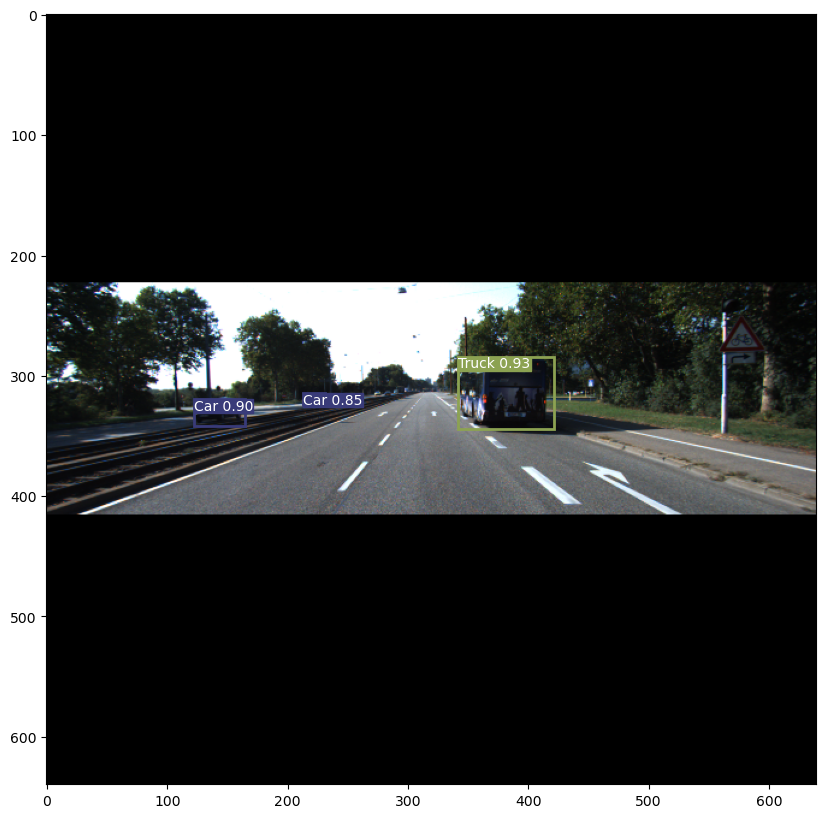


IMAGE 2
Predictions after NMS: 3


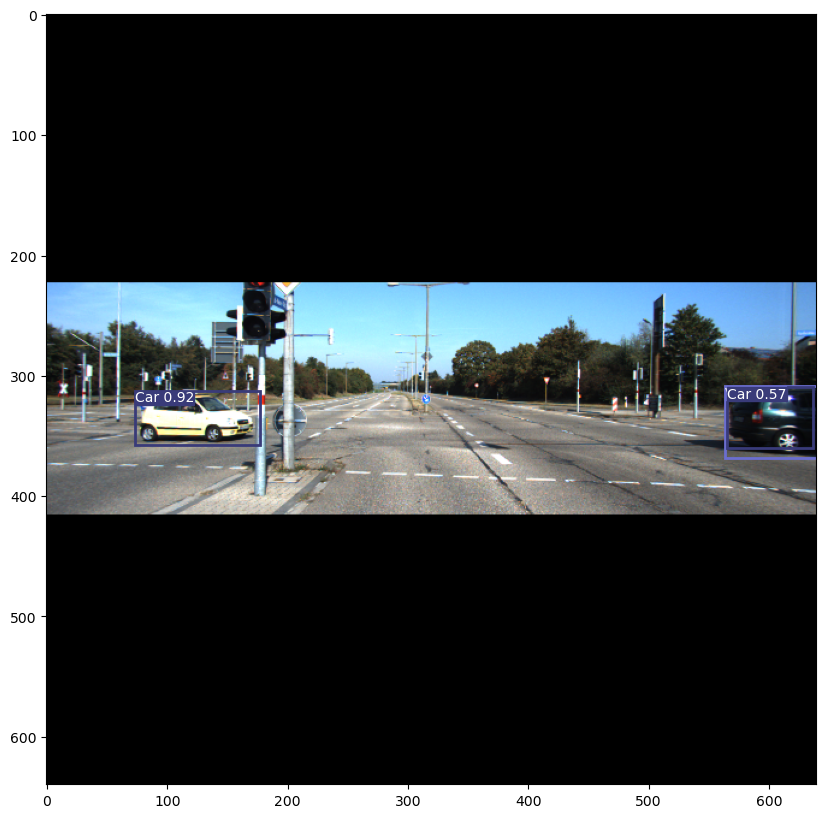


IMAGE 3
Predictions after NMS: 6


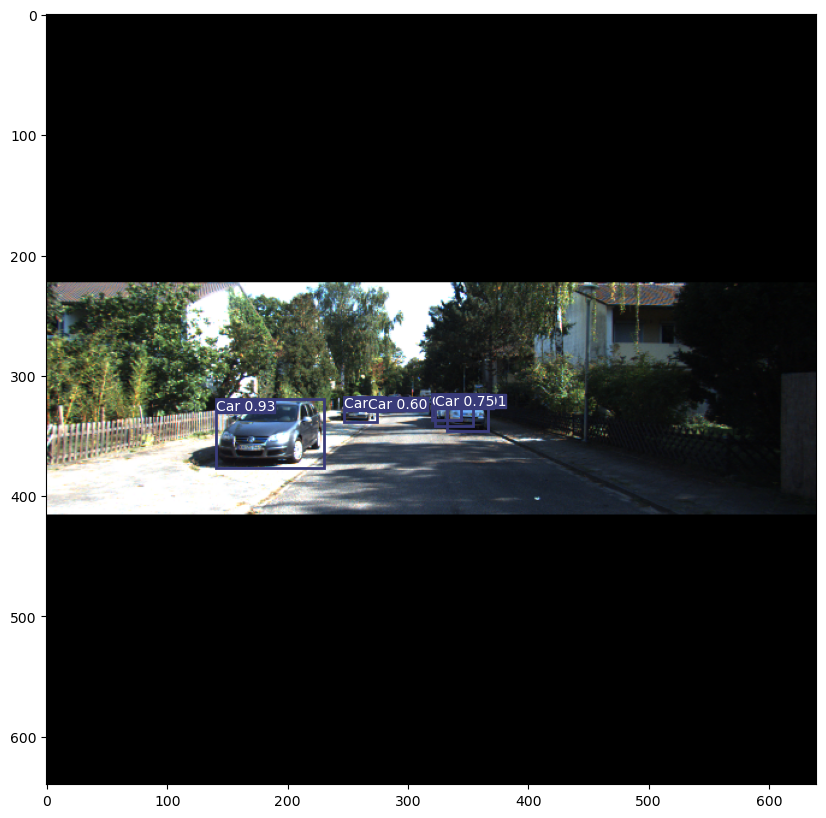


IMAGE 4
Predictions after NMS: 14


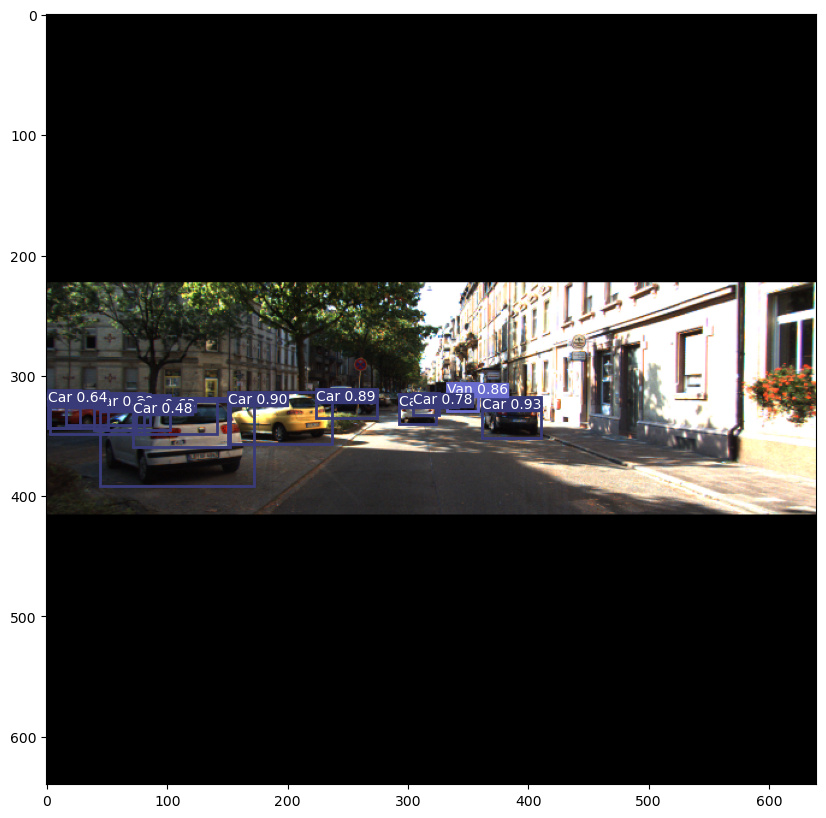


IMAGE 5
Predictions after NMS: 10


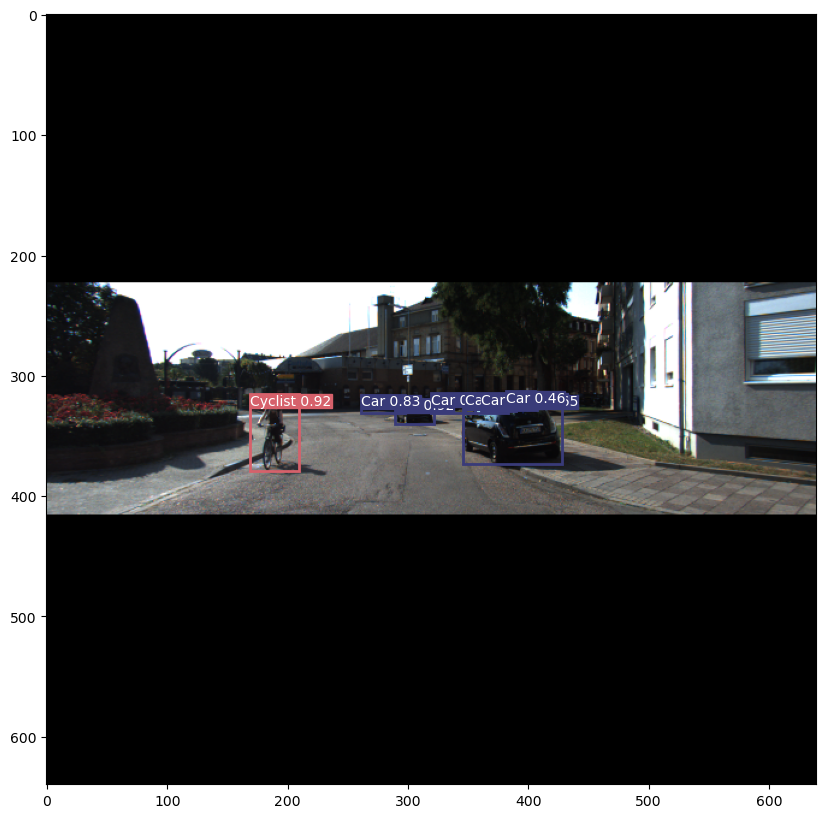


IMAGE 6
Predictions after NMS: 3


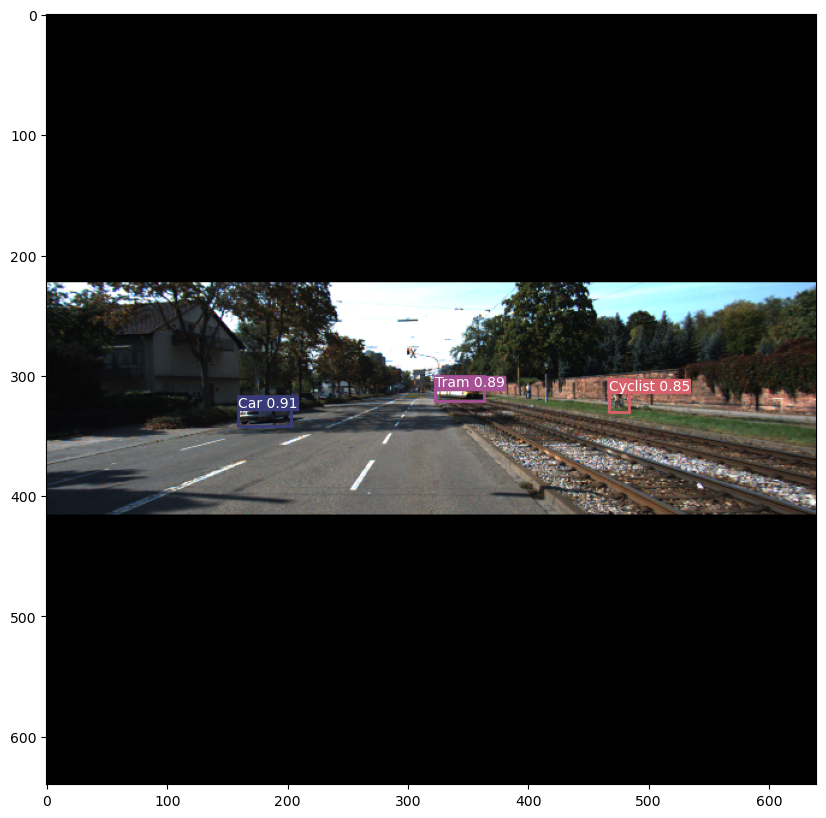


IMAGE 7
Predictions after NMS: 4


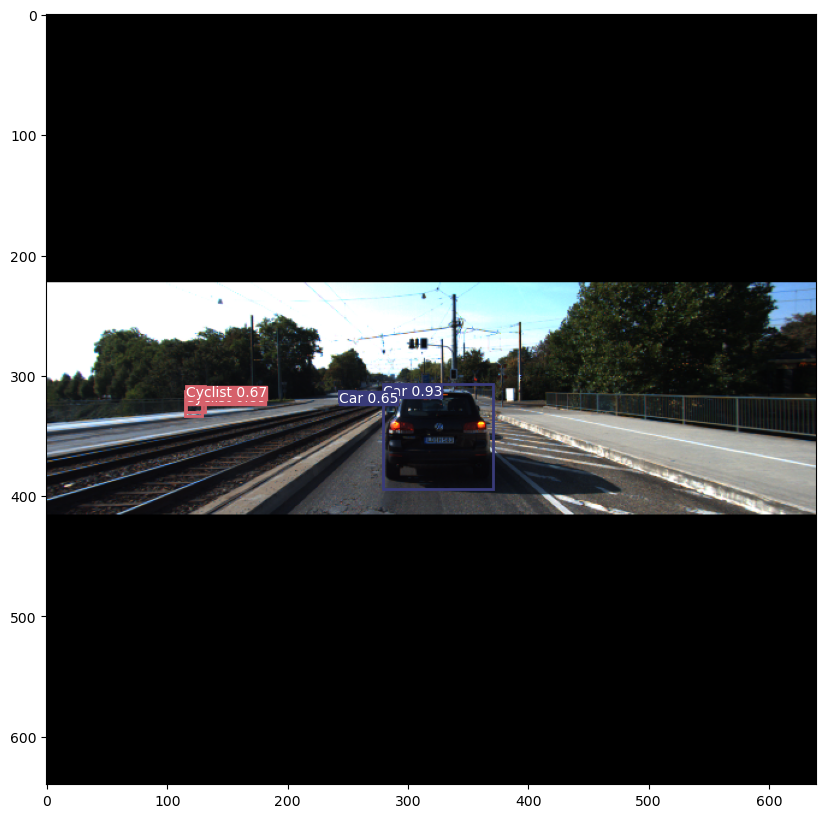


IMAGE 8
Predictions after NMS: 1


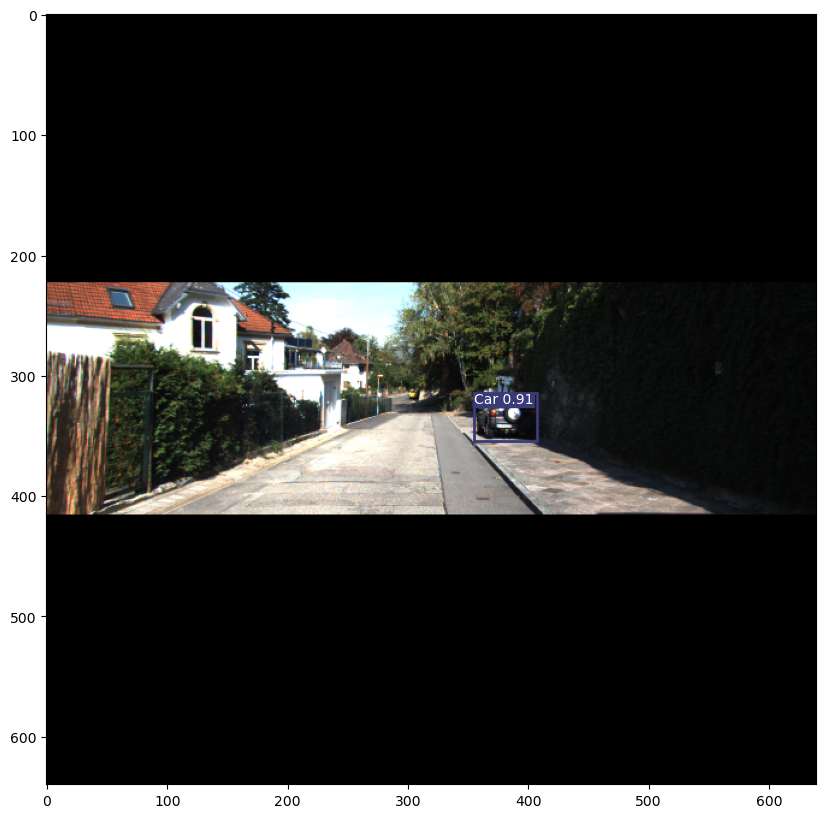

In [18]:
IOU_TRESH = 0.6
THRESH = 0.45

seed = 999

valid_gen = torch.Generator()
valid_gen.manual_seed(seed)
  
test_dataset = SiStNetDataset(
    transforms=test_transforms,
    S=[RESIZE_TO // 32, RESIZE_TO // 16],
    img_dir=valid_data_path,
    label_dir=valid_lbl_path,
    anchors=ANCHORS,
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    shuffle=False,
    drop_last=False,
)

plot_examples(model, test_loader, THRESH, IOU_TRESH, scaled_anchors)
